## Random Forest

### Workflow:
#### 1. Remove features not present in the NIBRS dataset to ensure consistency
#### 2. Retrain the model using GridSearchCV with 5-fold cross-validation
#### 3. Evaluate the model on the NIBRS dataset
#### 4. Notice performance drop and investigate possible causes
#### 5. Tune classification threshold (0.2 found to be more suitable)
#### 6. Analyze cross-dataset differences and identify domain shift
#### 7. Save the final model

In [1]:
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix
)
FEATURE_DIR = Path("../data/feature_engineering")

X_train = pd.read_csv(FEATURE_DIR / "X_train.csv")
X_test = pd.read_csv(FEATURE_DIR / "X_test.csv")
y_train = pd.read_csv(FEATURE_DIR / "y_train.csv").squeeze()  # Convert to 1D Series
y_test = pd.read_csv(FEATURE_DIR / "y_test.csv").squeeze()

In [2]:
# Remove latitude/longitude and district one-hot columns
drop_cols = ["lat_mean", "lon_mean"] + [col for col in X_train.columns if col.startswith("district_")]

X_train_aligned = X_train.drop(columns=drop_cols, errors="ignore").copy()
X_test_aligned = X_test.drop(columns=drop_cols, errors="ignore").copy()

In [3]:
X = pd.read_csv("../data/nibrs/X_test_nibrs.csv")
y = pd.read_csv("../data/nibrs/y_test_nibrs.csv")

# Filter: only keep City-type agencies for fairer comparison with Chicago urban communities
meta = pd.read_csv("../data/nibrs/nibrs_meta.csv")
city_ids = meta[meta["agency_type_name"] == "City"]["agency_id"]

data = X.merge(y, on="agency_id", how="inner")
data = data[data["agency_id"].isin(city_ids)]

print(f"NIBRS agencies after City filter: {len(data)} (original: {len(X)})")

X_nibrs_model = data.drop(columns=["agency_id", "label"])
y_nibrs = data["label"]

NIBRS agencies after City filter: 1133 (original: 1914)


In [4]:
# align the order
X_nibrs_model = X_nibrs_model.reindex(columns=X_train_aligned.columns)

print("Chicago aligned feature count:", len(X_train_aligned.columns))
print("NIBRS feature count:", len(X_nibrs_model.columns))

print("Are columns exactly the same?")
print(list(X_train_aligned.columns) == list(X_nibrs_model.columns))

Chicago aligned feature count: 11
NIBRS feature count: 11
Are columns exactly the same?
True


In [12]:
meta[meta["agency_id"].isin(data["agency_id"])]["region_name"].value_counts()

region_name
South        675
West         328
Northeast    130
Name: count, dtype: int64

In [5]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Stratified k-fold cross validation ,k=5
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#coarse search
param_grid = {
    ## Number of trees in the forest. More trees generally improve model stability but increase computation time.
    "n_estimators":[100,200,300],
    
    # max_depth is the maximum number of levels that a decision tree can grow, controlling the complexity of the model.
    "max_depth":[None,10,20],
   
    # Minimum number of samples required at a leaf node. Larger values produce smoother decision boundaries and reduce overfitting.
    "min_samples_leaf":[1,2,4],
   
    # Number of features considered at each split. Introduces randomness and reduces correlation between trees.
    "max_features":["sqrt","log2"],
    
    # Automatically adjusts class weights inversely proportional to class frequencies to handle class imbalance.
    "class_weight":["balanced"]
}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring=scoring,
    refit="roc_auc",   
    n_jobs=-1,
    # Displays progress information during model training.
    verbose=1
)

grid.fit(X_train_aligned,y_train)

print("Best Parameters (coarse search):")
print(grid.best_params_)

print("\nBest CV Score (coarse search):")
print(grid.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters (coarse search):
{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}

Best CV Score (coarse search):
0.9545750452079567


In [6]:
#fine search
param_grid_fine = {
    "n_estimators": [60, 80, 100, 120],
    "max_depth": [None, 10, 15, 20],
    "max_features": ["sqrt"],
    "min_samples_leaf": [1, 2, 3],
    "class_weight": ["balanced"]
}
grid_fine = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_fine,
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_fine.fit(X_train_aligned, y_train)

print("Best Parameters (Fine Search):")
print(grid_fine.best_params_)

print("\nBest CV Score (Fine Search):")
print(grid_fine.best_score_)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters (Fine Search):
{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}

Best CV Score (Fine Search):
0.9545750452079567


In [7]:
# predict
best_rf = grid_fine.best_estimator_
y_pred = best_rf.predict(X_test_aligned)
y_prob = best_rf.predict_proba(X_test_aligned)[:, 1]   # calculate probability for binary classification


print("Chicago Test Set Results:")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Chicago Test Set Results:
Accuracy : 0.9221
Precision: 0.9375
Recall   : 0.7500
F1-score : 0.8333
ROC-AUC  : 0.9702


## ROC Curve

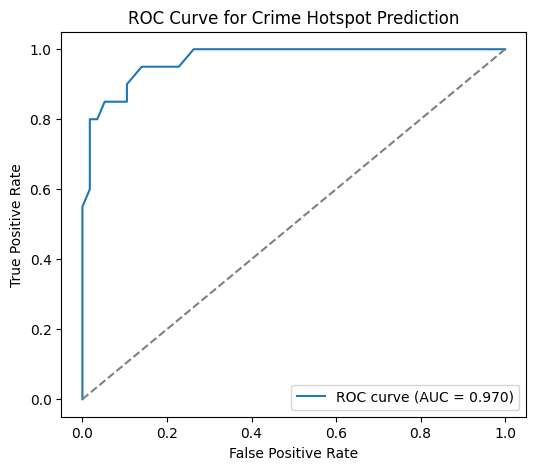

In [8]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Crime Hotspot Prediction")

plt.legend()

plt.show()

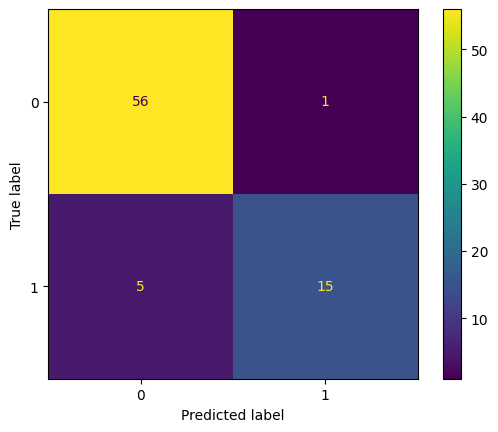

In [9]:
#ConfusionMatrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [10]:
importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train_aligned.columns
).sort_values(ascending=False)

print("Top 10 features")
print(importance.head(10))

Top 10 features
theft_ratio                 0.164517
battery_ratio               0.134990
deceptive_practice_ratio    0.119948
commercial_ratio            0.117213
other_ratio                 0.106556
other_crime_ratio           0.092660
criminal_damage_ratio       0.086185
residential_ratio           0.077322
public_ratio                0.061690
assault_ratio               0.038075
dtype: float64


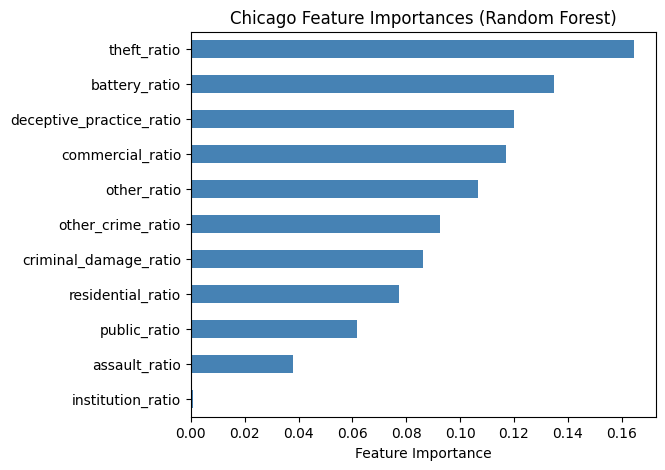

In [11]:
top_features = importance.head(11)

plt.figure(figsize=(6,5))

top_features.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.xlabel("Feature Importance")
plt.title("Chicago Feature Importances (Random Forest)")

plt.show()

# NIBRS Dataset Application

In [12]:
y_pred_nibrs = best_rf.predict(X_nibrs_model)
y_prob_nibrs = best_rf.predict_proba(X_nibrs_model)[:, 1]   # calculate probability for binary classification

print("NIBRS Test Set Results:")
print(f"Accuracy : {accuracy_score(y_nibrs, y_pred_nibrs):.4f}")
print(f"Precision: {precision_score(y_nibrs, y_pred_nibrs):.4f}")
print(f"Recall   : {recall_score(y_nibrs, y_pred_nibrs):.4f}")
print(f"F1-score : {f1_score(y_nibrs, y_pred_nibrs):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_nibrs, y_prob_nibrs):.4f}")

NIBRS Test Set Results:
Accuracy : 0.6293
Precision: 0.3134
Recall   : 0.0532
F1-score : 0.0909
ROC-AUC  : 0.5556


In [13]:
print("Predicted positives:", y_pred_nibrs.sum())
print("Actual positives:", y_nibrs.sum())

Predicted positives: 67
Actual positives: 395


## ROC Curve

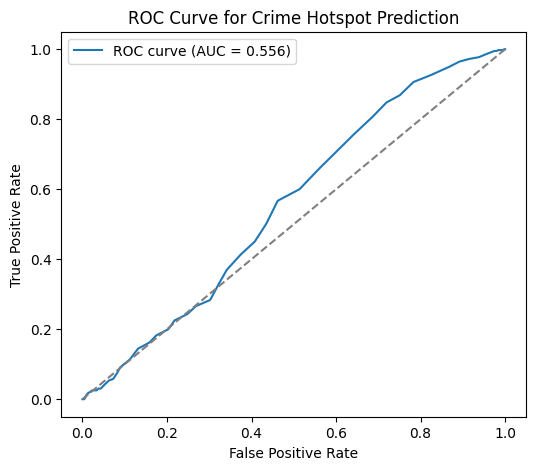

In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_nibrs, y_prob_nibrs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Crime Hotspot Prediction")

plt.legend()

plt.show()

## Confusion Matrix

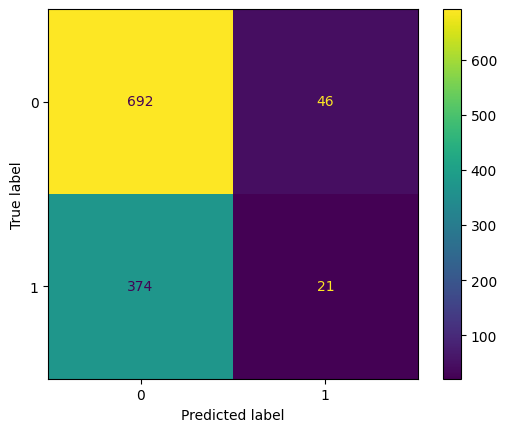

In [15]:
#ConfusionMatrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_nibrs, y_pred_nibrs)
plt.show()

# Threshold Analysis

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.5, 0.4, 0.3, 0.2]

for t in thresholds:
    y_pred_t = (y_prob_nibrs >= t).astype(int)
    
    precision = precision_score(y_nibrs, y_pred_t)
    recall = recall_score(y_nibrs, y_pred_t)
    f1 = f1_score(y_nibrs, y_pred_t)
    
    print(f"\nThreshold = {t}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-score:  {f1:.3f}")


Threshold = 0.5
Precision: 0.306
Recall:    0.056
F1-score:  0.094

Threshold = 0.4
Precision: 0.344
Recall:    0.243
F1-score:  0.285

Threshold = 0.3
Precision: 0.386
Recall:    0.658
F1-score:  0.487

Threshold = 0.2
Precision: 0.367
Recall:    0.965
F1-score:  0.531


In [17]:
# set new threshold
threshold = 0.2
y_pred_nibrs_03 = (y_prob_nibrs >= threshold).astype(int)

In [18]:
print("NIBRS Test Set Results:")
print(f"Accuracy : {accuracy_score(y_nibrs, y_pred_nibrs_03):.4f}")
print(f"Precision: {precision_score(y_nibrs, y_pred_nibrs_03):.4f}")
print(f"Recall   : {recall_score(y_nibrs, y_pred_nibrs_03):.4f}")
print(f"F1-score : {f1_score(y_nibrs, y_pred_nibrs_03):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_nibrs, y_prob_nibrs):.4f}")

NIBRS Test Set Results:
Accuracy : 0.4069
Precision: 0.3667
Recall   : 0.9646
F1-score : 0.5314
ROC-AUC  : 0.5556


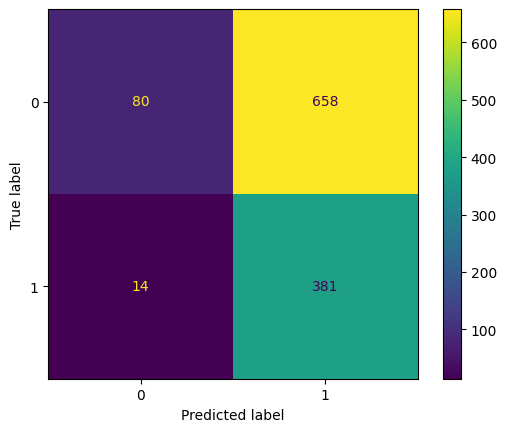

In [19]:
#ConfusionMatrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_nibrs, y_pred_nibrs_03)
plt.show()

# Cross-dataset explanation

In [20]:
print(X_train_aligned.mean())
print(X_nibrs_model.mean())

commercial_ratio            0.030808
institution_ratio           0.000002
other_ratio                 0.324500
public_ratio                0.315784
residential_ratio           0.328907
theft_ratio                 0.219838
battery_ratio               0.183144
criminal_damage_ratio       0.117979
assault_ratio               0.082332
deceptive_practice_ratio    0.078386
other_crime_ratio           0.318322
dtype: float64
commercial_ratio            0.177155
institution_ratio           0.033645
other_ratio                 0.141201
public_ratio                0.293589
residential_ratio           0.354410
theft_ratio                 0.378176
battery_ratio               0.214115
criminal_damage_ratio       0.104525
assault_ratio               0.029894
deceptive_practice_ratio    0.075990
other_crime_ratio           0.197300
dtype: float64


In [21]:
# use nibrs data to train new model
#to get feature importance
best_rf_2 = grid_fine.best_estimator_

best_rf_2.fit(X_nibrs_model,y_nibrs)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
importance_nibrs = pd.Series(
    best_rf_2.feature_importances_,
    index=X_nibrs_model.columns
).sort_values(ascending=False)

print("Top 10 features")
print(importance_nibrs.head(10))

Top 10 features
commercial_ratio            0.142427
residential_ratio           0.104173
public_ratio                0.102845
theft_ratio                 0.102775
assault_ratio               0.100631
deceptive_practice_ratio    0.081964
institution_ratio           0.079080
other_crime_ratio           0.076603
battery_ratio               0.072057
other_ratio                 0.069745
dtype: float64


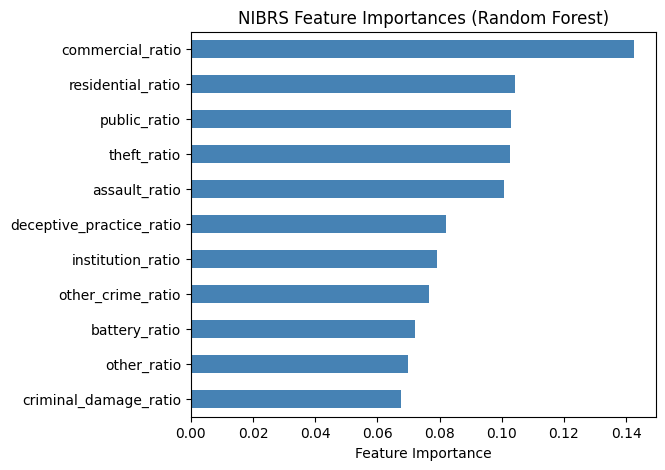

In [23]:
top_features = importance_nibrs.head(11)

plt.figure(figsize=(6,5))

top_features.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.xlabel("Feature Importance")
plt.title("NIBRS Feature Importances (Random Forest)")

plt.show()

In [24]:
import os
import joblib

os.makedirs('../src/models', exist_ok=True)

joblib.dump(best_rf, '../src/models/best_rf_nibrs.pkl')

print('Model saved to src/models/best_rf_nibrs.pkl')

Model saved to src/models/best_rf_nibrs.pkl
